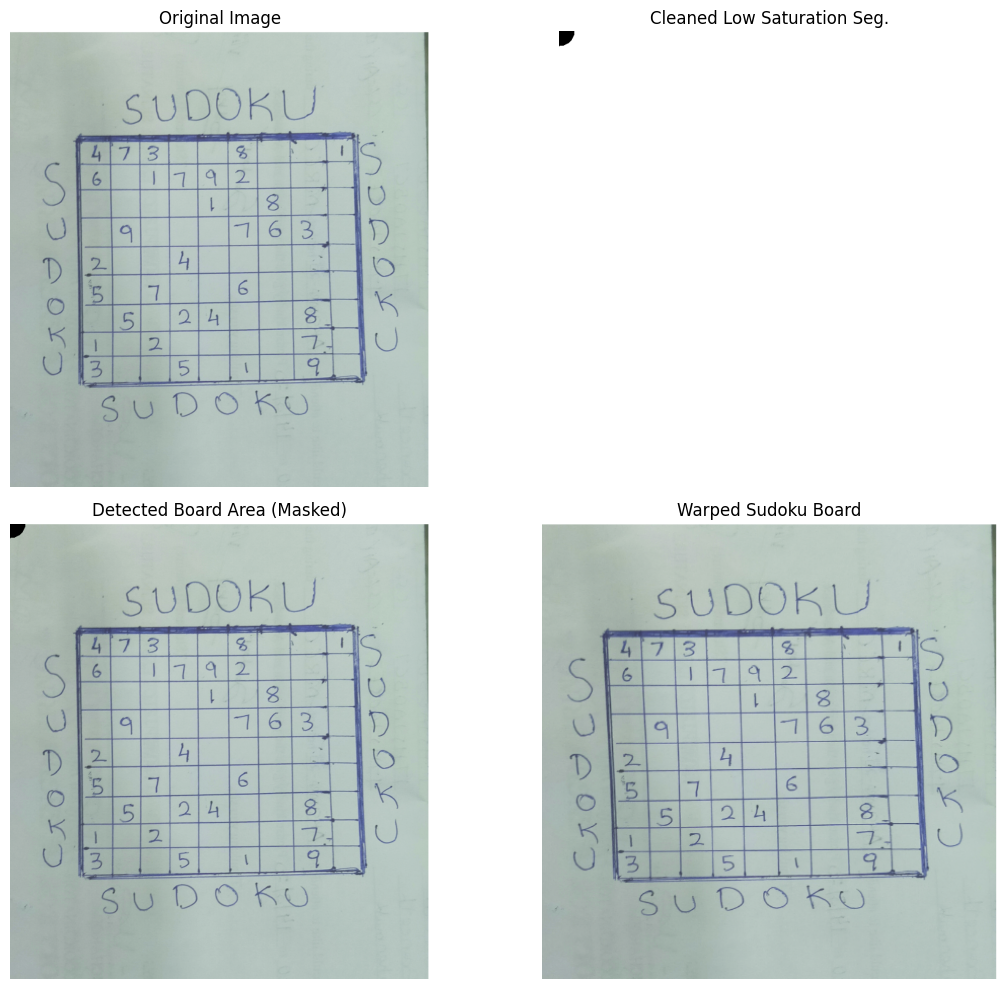

In [ ]:
import skimage.color
import skimage.io
import skimage.measure
import skimage.morphology
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Test multiple images
image_dir = "/home/tomas/PYT/motustom/semestral/app/tests/images"
test_images = ["image1.jpg", "image2.png", "image3.png", "image4.png"]

class EnhancedSudokuDetector:
    """Enhanced Sudoku detector optimized for blue pen handwriting"""
    
    def __init__(self, output_size=450):
        self.output_size = output_size
    
    def detect_blue_pen_writing(self, image):
        """Enhanced blue pen detection using multiple color spaces"""
        if len(image.shape) != 3:
            return np.zeros(image.shape[:2], dtype=np.uint8)
        
        # Method 1: Blue channel enhancement
        blue_channel = image[:,:,2]
        red_channel = image[:,:,0]
        green_channel = image[:,:,1]
        
        # Enhance blue by comparing with other channels
        blue_enhanced = np.maximum(0, blue_channel.astype(np.int16) - 
                                 (red_channel.astype(np.int16) + green_channel.astype(np.int16)) // 3)
        blue_enhanced = np.clip(blue_enhanced, 0, 255).astype(np.uint8)
        
        # Threshold enhanced blue
        _, blue_thresh = cv2.threshold(blue_enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        # Method 2: HSV blue detection with wider range
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        # Wider blue range for different pen shades
        lower_blue1 = np.array([100, 30, 30])
        upper_blue1 = np.array([140, 255, 255])
        blue_mask1 = cv2.inRange(hsv, lower_blue1, upper_blue1)
        
        # Additional range for darker blues
        lower_blue2 = np.array([110, 50, 20])
        upper_blue2 = np.array([130, 255, 200])
        blue_mask2 = cv2.inRange(hsv, lower_blue2, upper_blue2)
        
        # Method 3: LAB color space
        lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
        b_channel = lab[:,:,2]
        # Blue in LAB has higher b values
        _, lab_blue = cv2.threshold(b_channel, 135, 255, cv2.THRESH_BINARY)
        
        # Combine all methods
        combined_blue = cv2.bitwise_or(blue_thresh, blue_mask1)
        combined_blue = cv2.bitwise_or(combined_blue, blue_mask2)
        combined_blue = cv2.bitwise_or(combined_blue, lab_blue)
        
        # Clean up noise
        kernel = np.ones((2,2), np.uint8)
        combined_blue = cv2.morphologyEx(combined_blue, cv2.MORPH_OPEN, kernel)
        
        return combined_blue
    
    def detect_grid_structure(self, gray):
        """Detect grid lines and structure"""
        # Gaussian blur to reduce noise
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Multiple edge detection approaches
        edges1 = cv2.Canny(blurred, 30, 100)
        edges2 = cv2.Canny(blurred, 50, 150)
        edges = cv2.bitwise_or(edges1, edges2)
        
        # Detect horizontal and vertical lines separately
        # Horizontal lines
        horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
        horizontal_lines = cv2.morphologyEx(edges, cv2.MORPH_OPEN, horizontal_kernel)
        
        # Vertical lines
        vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
        vertical_lines = cv2.morphologyEx(edges, cv2.MORPH_OPEN, vertical_kernel)
        
        # Combine grid lines
        grid_lines = cv2.bitwise_or(horizontal_lines, vertical_lines)
        
        return grid_lines, edges
    
    def adaptive_content_detection(self, gray):
        """Adaptive detection for handwritten content"""
        # Multiple adaptive thresholding approaches
        adapt1 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                      cv2.THRESH_BINARY_INV, 11, 2)
        adapt2 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                      cv2.THRESH_BINARY_INV, 15, 4)
        adapt3 = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                      cv2.THRESH_BINARY_INV, 19, 6)
        
        # Combine adaptive results
        combined_adapt = cv2.bitwise_or(adapt1, adapt2)
        combined_adapt = cv2.bitwise_or(combined_adapt, adapt3)
        
        return combined_adapt
    
    def detect_sudoku_board(self, image):
        """Main detection method combining all approaches"""
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image.copy()
        
        # Get all detection results
        blue_pen = self.detect_blue_pen_writing(image)
        grid_lines, edges = self.detect_grid_structure(gray)
        content = self.adaptive_content_detection(gray)
        
        # Create weighted combination
        combined = np.zeros_like(gray, dtype=np.float32)
        
        # Weight the different detection methods
        combined += blue_pen.astype(np.float32) * 0.4  # Blue pen gets high weight
        combined += grid_lines.astype(np.float32) * 0.3  # Grid structure important
        combined += content.astype(np.float32) * 0.2  # General content
        combined += edges.astype(np.float32) * 0.1  # Edge information
        
        # Normalize and threshold
        combined = np.clip(combined, 0, 255).astype(np.uint8)
        final_mask = cv2.threshold(combined, 80, 255, cv2.THRESH_BINARY)[1]
        
        # Morphological operations to clean up
        kernel_close = np.ones((7,7), np.uint8)
        final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_CLOSE, kernel_close)
        
        kernel_open = np.ones((3,3), np.uint8)
        final_mask = cv2.morphologyEx(final_mask, cv2.MORPH_OPEN, kernel_open)
        
        return final_mask, blue_pen, grid_lines, content, edges
    
    def find_best_rectangle(self, mask):
        """Find the best rectangular contour for the Sudoku board"""
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if not contours:
            return None
        
        # Sort by area and filter
        image_area = mask.shape[0] * mask.shape[1]
        min_area = image_area * 0.05  # At least 5% of image
        max_area = image_area * 0.85  # At most 85% of image
        
        valid_contours = [c for c in contours if min_area < cv2.contourArea(c) < max_area]
        
        if not valid_contours:
            return None
        
        valid_contours = sorted(valid_contours, key=cv2.contourArea, reverse=True)
        
        # Try to find rectangular contours
        for contour in valid_contours:
            # Try different approximation levels
            for epsilon_factor in [0.01, 0.02, 0.03, 0.05, 0.08]:
                epsilon = epsilon_factor * cv2.arcLength(contour, True)
                approx = cv2.approxPolyDP(contour, epsilon, True)
                
                if len(approx) == 4:
                    # Check if roughly square
                    rect = cv2.minAreaRect(contour)
                    width, height = rect[1]
                    if width > 0 and height > 0:
                        aspect_ratio = max(width, height) / min(width, height)
                        if aspect_ratio < 2.5:  # Allow some tolerance
                            return approx
        
        # Fallback: bounding rectangle of largest contour
        largest_contour = valid_contours[0]
        x, y, w, h = cv2.boundingRect(largest_contour)
        return np.array([[[x, y]], [[x+w, y]], [[x+w, y+h]], [[x, y+h]]], dtype=np.int32)
    
    def order_points(self, pts):
        """Order points clockwise: top-left, top-right, bottom-right, bottom-left"""
        rect = np.zeros((4, 2), dtype="float32")
        pts = pts.reshape(4, 2)
        
        # Sum and difference method
        s = pts.sum(axis=1)
        rect[0] = pts[np.argmin(s)]  # top-left
        rect[2] = pts[np.argmax(s)]  # bottom-right
        
        diff = np.diff(pts, axis=1)
        rect[1] = pts[np.argmin(diff)]  # top-right
        rect[3] = pts[np.argmax(diff)]  # bottom-left
        
        return rect
    
    def extract_board(self, image, corners):
        """Extract and warp the Sudoku board"""
        ordered_corners = self.order_points(corners)
        
        # Destination points
        dst = np.array([
            [0, 0],
            [self.output_size-1, 0],
            [self.output_size-1, self.output_size-1],
            [0, self.output_size-1]
        ], dtype="float32")
        
        # Perspective transform
        M = cv2.getPerspectiveTransform(ordered_corners, dst)
        warped = cv2.warpPerspective(image, M, (self.output_size, self.output_size))
        
        return warped

# Initialize detector
detector = EnhancedSudokuDetector(output_size=450)

# Test on all available images
for img_name in test_images:
    img_path = os.path.join(image_dir, img_name)
    
    if os.path.exists(img_path):
        print(f"\n=== Processing {img_name} ===")
        
        try:
            # Load image
            if img_name.endswith('.jpg'):
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                image = skimage.io.imread(img_path)
            
            print(f"Image shape: {image.shape}")
            
            # Detect Sudoku board
            combined_mask, blue_pen, grid_lines, content, edges = detector.detect_sudoku_board(image)
            
            # Find rectangle
            corners = detector.find_best_rectangle(combined_mask)
            
            success = corners is not None
            
            # Extract board if corners found
            warped_board = None
            if success:
                try:
                    warped_board = detector.extract_board(image, corners)
                    print(f"✓ Successfully extracted Sudoku board")
                except Exception as e:
                    print(f"✗ Failed to extract board: {e}")
                    success = False
            else:
                print(f"✗ No valid corners found")
            
            # Visualization
            plt.figure(figsize=(18, 12))
            
            # Original
            plt.subplot(3, 4, 1)
            plt.imshow(image)
            plt.title(f"Original: {img_name}")
            plt.axis('off')
            
            # Blue pen detection
            plt.subplot(3, 4, 2)
            plt.imshow(blue_pen, cmap='gray')
            plt.title("Blue Pen Detection")
            plt.axis('off')
            
            # Grid lines
            plt.subplot(3, 4, 3)
            plt.imshow(grid_lines, cmap='gray')
            plt.title("Grid Lines")
            plt.axis('off')
            
            # Content detection
            plt.subplot(3, 4, 4)
            plt.imshow(content, cmap='gray')
            plt.title("Content Detection")
            plt.axis('off')
            
            # Edges
            plt.subplot(3, 4, 5)
            plt.imshow(edges, cmap='gray')
            plt.title("Edges")
            plt.axis('off')
            
            # Combined mask
            plt.subplot(3, 4, 6)
            plt.imshow(combined_mask, cmap='gray')
            plt.title("Combined Mask")
            plt.axis('off')
            
            # Detected corners
            plt.subplot(3, 4, 7)
            vis_image = image.copy()
            if corners is not None:
                cv2.drawContours(vis_image, [corners], -1, (255, 0, 0), 3)
                # Draw corner points
                for point in corners.reshape(-1, 2):
                    cv2.circle(vis_image, tuple(point), 8, (0, 255, 0), -1)
            plt.imshow(vis_image)
            plt.title("Detected Board")
            plt.axis('off')
            
            # Final result
            plt.subplot(3, 4, 8)
            if success and warped_board is not None:
                plt.imshow(warped_board)
                plt.title("Extracted Board")
            else:
                plt.imshow(image)
                plt.title("Extraction Failed")
            plt.axis('off')
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Error processing {img_name}: {e}")
            import traceback
            traceback.print_exc()
    else:
        print(f"Image {img_name} not found")

print("\nSudoku detection testing completed!")